In [1]:
import pandas as pd
import os

# 1. 작업 경로 설정
base_path = r'C:\Users\sl177\OneDrive - University of Illinois - Urbana\02_Paper Work\01_Paper(CANOPY)\01_SWAT Uncertainty\02_Sobol\9_Gumbel risk analysis'
obs_filename = 'Data 01 Annual Max Water Year - Observation.csv'
sim_filename = 'Data 02 Anual Max Water Year - Sobol Simulation.csv'

# 2. 파일 전체 경로 생성
obs_path = os.path.join(base_path, obs_filename)
sim_path = os.path.join(base_path, sim_filename)

try:
    # 3. 데이터 로드
    obs_df = pd.read_csv(obs_path)
    sim_df = pd.read_csv(sim_path)

    # 4. 데이터 구조 확인 (첫 5행 및 정보 출력)
    print("--- [Observation Data Sample] ---")
    print(obs_df.head())
    print("\n--- [Observation Data Info] ---")
    print(obs_df.info())

    print("\n" + "="*50 + "\n")

    print("--- [Simulation Data Sample] ---")
    print(sim_df.head())
    print("\n--- [Simulation Data Info] ---")
    print(sim_df.info())

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다. 경로를 다시 확인해주세요: {e}")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")

--- [Observation Data Sample] ---
   water_year  annual_max_cms
0        1989      233.104281
1        1990      377.180397
2        1991      559.597522
3        1992      133.655516
4        1993      455.901230

--- [Observation Data Info] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   water_year      37 non-null     int64  
 1   annual_max_cms  37 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 724.0 bytes
None


--- [Simulation Data Sample] ---
   WaterYear    sim1   sim2   sim3   sim4    sim5   sim6    sim7   sim8  \
0       2012  260.50  430.0  562.6  560.8  309.50  153.0   802.7  377.0   
1       2013   73.34  152.8  193.9  237.0   99.88   81.5   377.0  172.5   
2       2014  116.90  527.3  581.4  697.8  275.90   87.6  1069.0  347.4   
3       2015  268.70  417.0  437.1  559.3  290.20  147.7   839.7  312.1   
4

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import t

# 1. 데이터 정렬 (Rank in ascending order)
obs_sorted = np.sort(obs_df['annual_max_cms'].values)
n = len(obs_sorted)
i = np.arange(1, n + 1)  # 순위 (1부터 n까지)

# 2. 비초과 확률 계산 (Gringorten's formula, alpha = 0.44)
alpha = 0.44
Fi = (i - alpha) / (n + 1 - 2 * alpha)

# 3. 표준화 변량 계산 (Standardized variate, yi)
# 식: yi = -ln(-ln(Fi))
yi = -np.log(-np.log(Fi))

# 결과 확인을 위한 데이터프레임 구성
step1_3_df = pd.DataFrame({
    'Rank(i)': i,
    'Observed_X': obs_sorted,
    'Prob_Fi': Fi,
    'Variate_yi': yi
})

print("--- [1단계 ~ 3단계 결과 (상위 5개)] ---")
print(step1_3_df.head())

--- [1단계 ~ 3단계 결과 (상위 5개)] ---
   Rank(i)  Observed_X   Prob_Fi  Variate_yi
0        1  133.655516  0.015086   -1.433649
1        2  186.947821  0.042026   -1.153564
2        3  187.565128  0.068966   -0.983631
3        4  188.023861  0.095905   -0.852028
4        5  189.213169  0.122845   -0.740428


In [3]:
# 4. 분포 매개변수 계산 (Compute distribution parameters)

# 데이터의 평균(mean)과 분산(variance) 계산
obs_mean = np.mean(obs_sorted)
obs_var = np.var(obs_sorted, ddof=1) # n-1로 나누는 불편분산 사용

# Scale parameter (a) 계산: sigma^2 = (pi^2 * a^2) / 6 식을 a에 대해 정리
# a = sqrt(6 * var / pi^2)
a_param = np.sqrt(6 * obs_var / np.pi**2)

# Location parameter (c) 계산: mu = c + 0.5772 * a 식을 c에 대해 정리
# c = mu - 0.5772 * a
c_param = obs_mean - 0.5772 * a_param

print("--- [4단계: Distribution Parameters] ---")
print(f"Sample Mean (μ): {obs_mean:.4f}")
print(f"Sample Variance (σ²): {obs_var:.4f}")
print(f"Scale Parameter (a): {a_param:.4f}")
print(f"Location Parameter (c): {c_param:.4f}")

--- [4단계: Distribution Parameters] ---
Sample Mean (μ): 503.0371
Sample Variance (σ²): 70309.5049
Scale Parameter (a): 206.7439
Location Parameter (c): 383.7045


In [4]:
from scipy.stats import t

# 5. Quantile 추정 (Estimate the quantiles)
# X_est = c + a * yi (수식 3.17)
X_est = c_param + a_param * yi

# 6. 추정치의 가변성 결정 (Determine the variability of the quantile estimates)
# var_X_est = (a^2 / n) * (1.17 + 0.196*yi + 1.099*yi^2) (수식 3.18)
var_X_est = (a_param**2 / n) * (1.17 + 0.196 * yi + 1.099 * yi**2)
std_error = np.sqrt(var_X_est) # 표준 오차

# 7. 95% 신뢰 한계 계산 (Compute confidence limits)
# t-value: 97.5% (두 갈래 테스트이므로 0.05/2), 자유도 n-1
t_val = t.ppf(0.975, n - 1)

lower_CL = X_est - t_val * std_error
upper_CL = X_est + t_val * std_error

# 결과 병합
analysis_df = pd.DataFrame({
    'Rank(i)': i,
    'Observed_X': obs_sorted,
    'Variate_yi': yi,
    'Estimated_X': X_est,
    'Lower_95_CL': lower_CL,
    'Upper_95_CL': upper_CL
})

print("--- [5~7단계: Quantile & Confidence Limits] ---")
print(analysis_df.tail()) # 상위 유량(큰 값) 쪽 확인

--- [5~7단계: Quantile & Confidence Limits] ---
    Rank(i)   Observed_X  Variate_yi  Estimated_X  Lower_95_CL  Upper_95_CL
32       33   801.423392    2.032013   803.810897   633.476222   974.145572
33       34   803.348938    2.294408   858.059477   670.478924  1045.640030
34       35   875.018877    2.638632   929.225612   718.573351  1139.877874
35       36  1080.004529    3.148080  1034.550837   789.105412  1279.996263
36       37  1441.610660    4.186383  1249.213849   931.443270  1566.984429


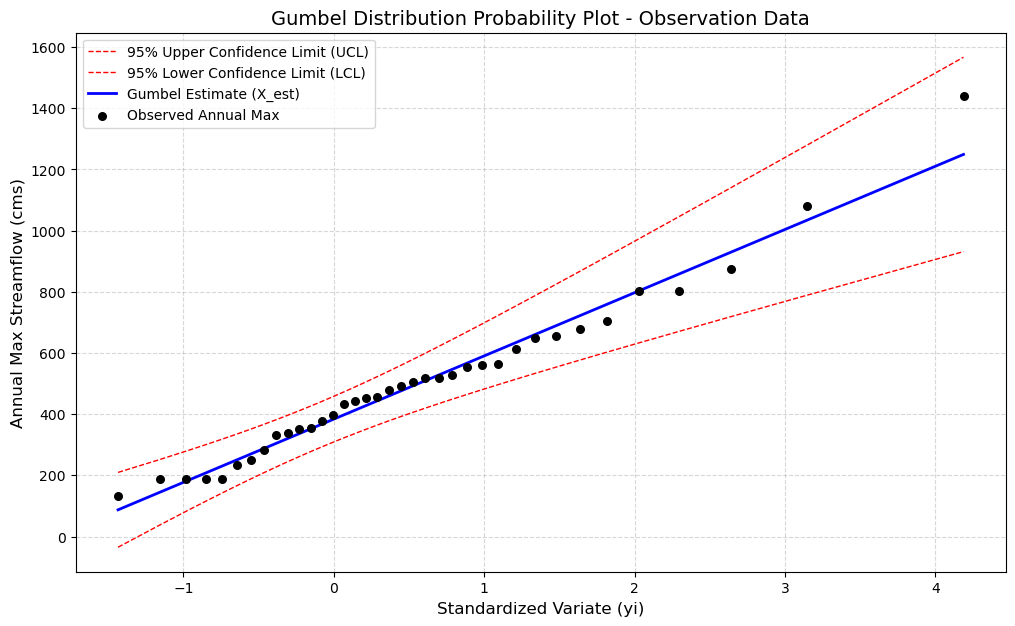

In [5]:
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(12, 7))

# 1. 신뢰 구간(UCL, LCL) 시각화 - 점선(Dashed line)
plt.plot(analysis_df['Variate_yi'], analysis_df['Upper_95_CL'], 'r--', linewidth=1, label='95% Upper Confidence Limit (UCL)')
plt.plot(analysis_df['Variate_yi'], analysis_df['Lower_95_CL'], 'r--', linewidth=1, label='95% Lower Confidence Limit (LCL)')

# 2. Gumbel 추정선(Xest) 시각화 - 실선(Solid line)
plt.plot(analysis_df['Variate_yi'], analysis_df['Estimated_X'], 'b-', linewidth=2, label='Gumbel Estimate (X_est)')

# 3. 실제 관측 데이터(Observed_X) 시각화 - 점(Scatter)
plt.scatter(analysis_df['Variate_yi'], analysis_df['Observed_X'], color='black', s=30, label='Observed Annual Max', zorder=3)

# 그래프 꾸미기
plt.title('Gumbel Distribution Probability Plot - Observation Data', fontsize=14)
plt.xlabel('Standardized Variate (yi)', fontsize=12)
plt.ylabel('Annual Max Streamflow (cms)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

# 그래프 출력
plt.show()

In [6]:
import numpy as np
import pandas as pd

# 1. 분석할 시뮬레이션 컬럼 리스트 (sim1 ~ sim5)
sim_cols = ['sim1', 'sim2', 'sim3', 'sim4', 'sim5']

# 결과를 저장할 딕셔너리
sim_results = {}

print(f"--- [Simulation Columns (sim1~sim5) Verification] ---")

for col in sim_cols:
    # A. 해당 컬럼 데이터 추출 및 오름차순 정렬
    data = sim_df[col].dropna().values
    data_sorted = np.sort(data)
    
    n = len(data_sorted)
    i = np.arange(1, n + 1)
    
    # B. Gringorten 공식 적용 (alpha = 0.44)
    alpha = 0.44
    Fi = (i - alpha) / (n + 1 - 2 * alpha)
    
    # C. 표준화 변량 yi 계산
    yi = -np.log(-np.log(Fi))
    
    # D. 데이터프레임 저장 (검증용)
    res_df = pd.DataFrame({
        'Rank(i)': i,
        'Sorted_X': data_sorted,
        'Prob_Fi': Fi,
        'Variate_yi': yi
    })
    
    sim_results[col] = res_df
    
    # 각 컬럼의 첫 5개 행 출력
    print(f"\n[{col} 결과 (n={n})]")
    print(res_df.head(5).to_string(index=False))

--- [Simulation Columns (sim1~sim5) Verification] ---

[sim1 결과 (n=9)]
 Rank(i)  Sorted_X  Prob_Fi  Variate_yi
       1     73.34 0.061404   -1.026145
       2     82.19 0.171053   -0.568595
       3    116.90 0.280702   -0.239381
       4    195.60 0.390351    0.061121
       5    256.00 0.500000    0.366513

[sim2 결과 (n=9)]
 Rank(i)  Sorted_X  Prob_Fi  Variate_yi
       1     152.8 0.061404   -1.026145
       2     184.4 0.171053   -0.568595
       3     294.1 0.280702   -0.239381
       4     352.9 0.390351    0.061121
       5     361.0 0.500000    0.366513

[sim3 결과 (n=9)]
 Rank(i)  Sorted_X  Prob_Fi  Variate_yi
       1     193.9 0.061404   -1.026145
       2     195.7 0.171053   -0.568595
       3     324.3 0.280702   -0.239381
       4     427.5 0.390351    0.061121
       5     437.1 0.500000    0.366513

[sim4 결과 (n=9)]
 Rank(i)  Sorted_X  Prob_Fi  Variate_yi
       1     237.0 0.061404   -1.026145
       2     281.7 0.171053   -0.568595
       3     428.5 0.280702   -0.23938

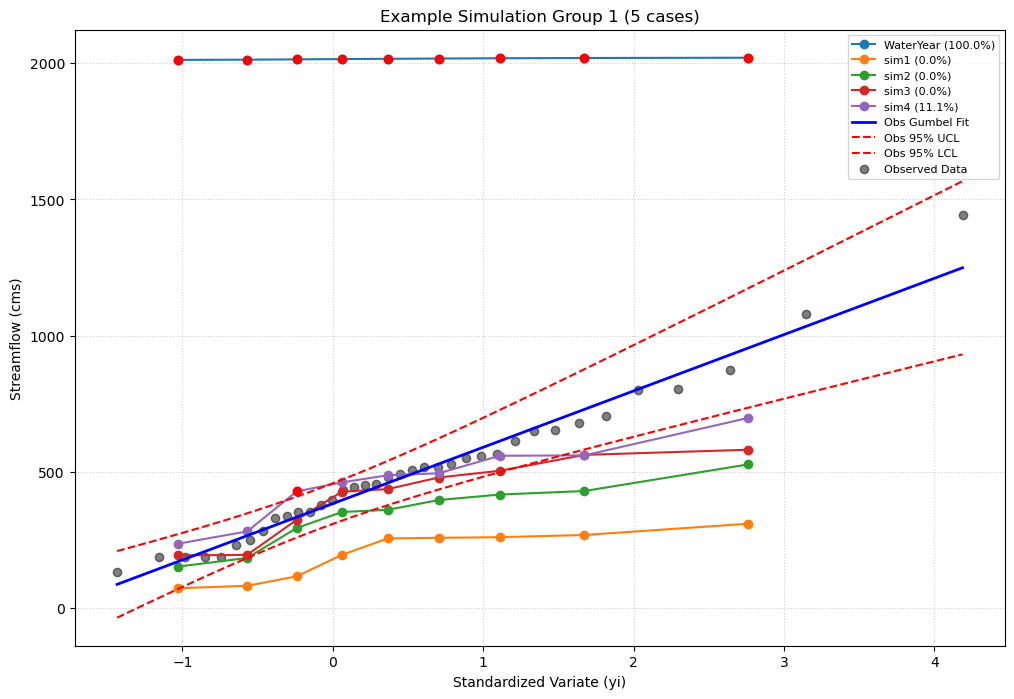

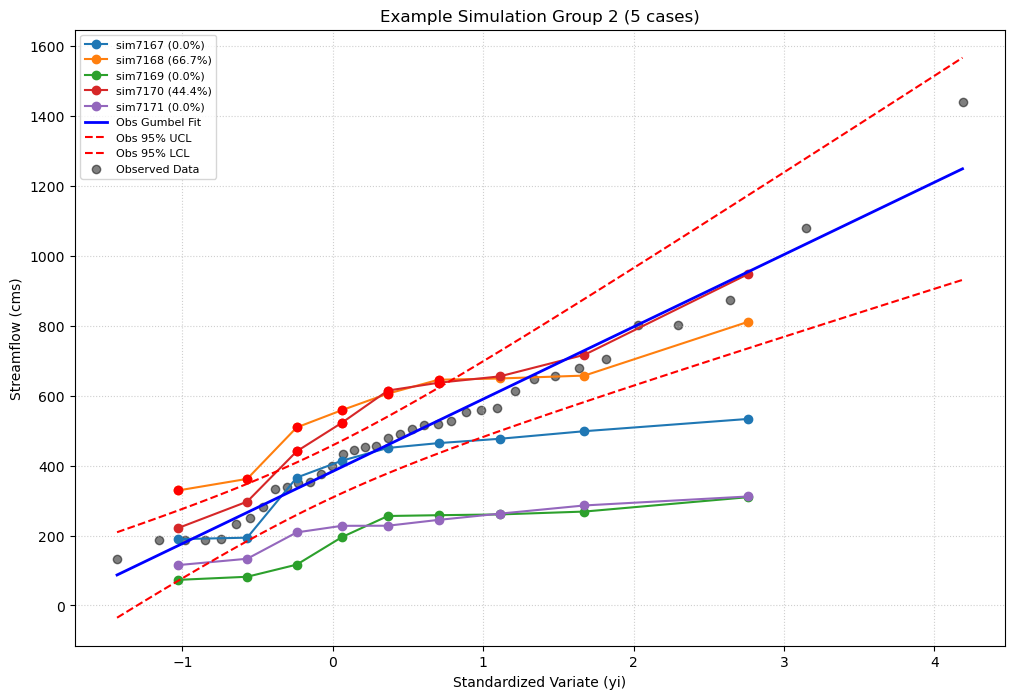

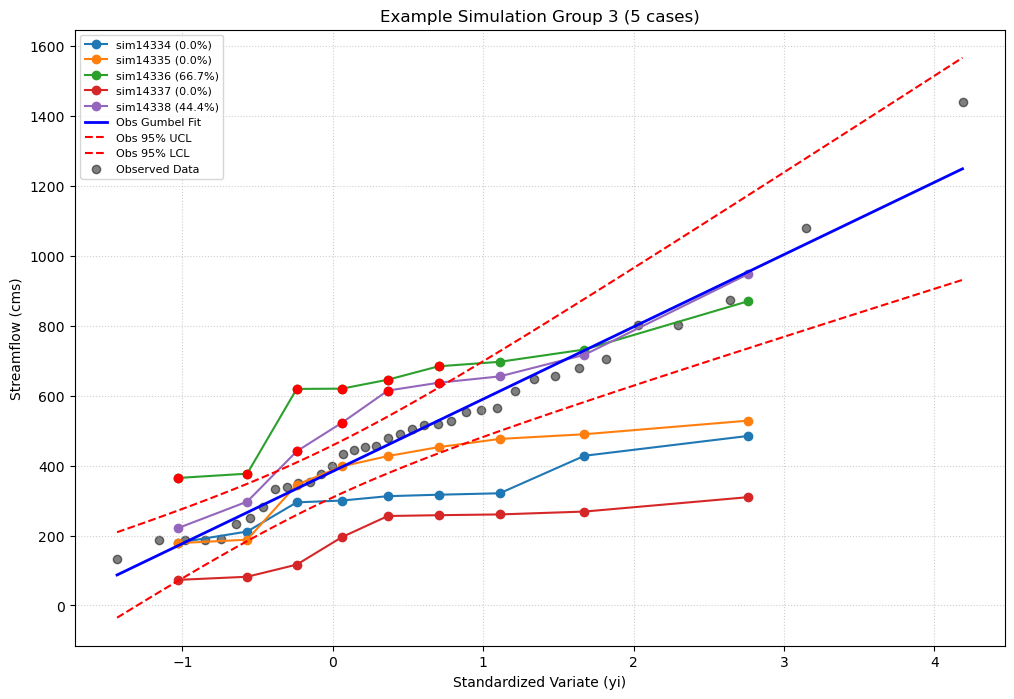

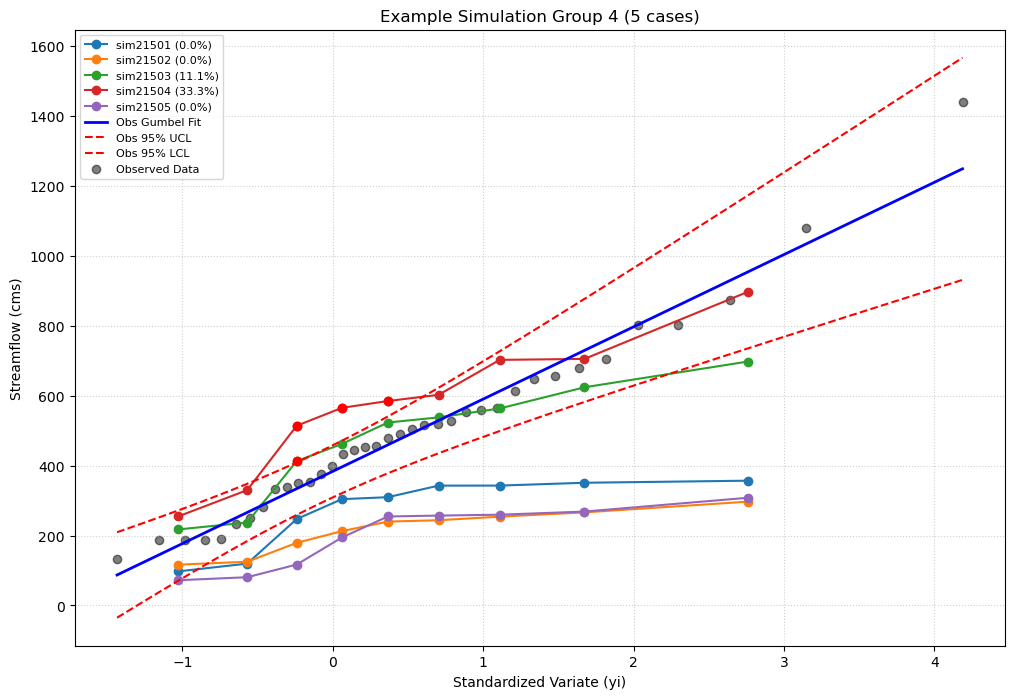

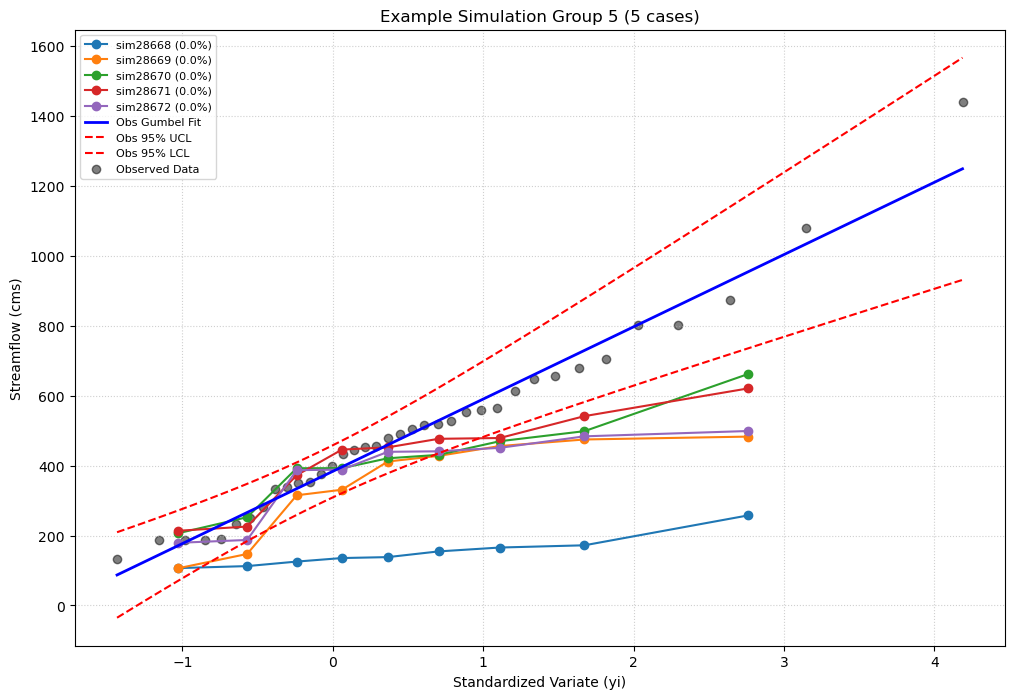

✅ Example groups saved.

Total simulations analyzed: 28673
Mean Flood Risk: 17.97%


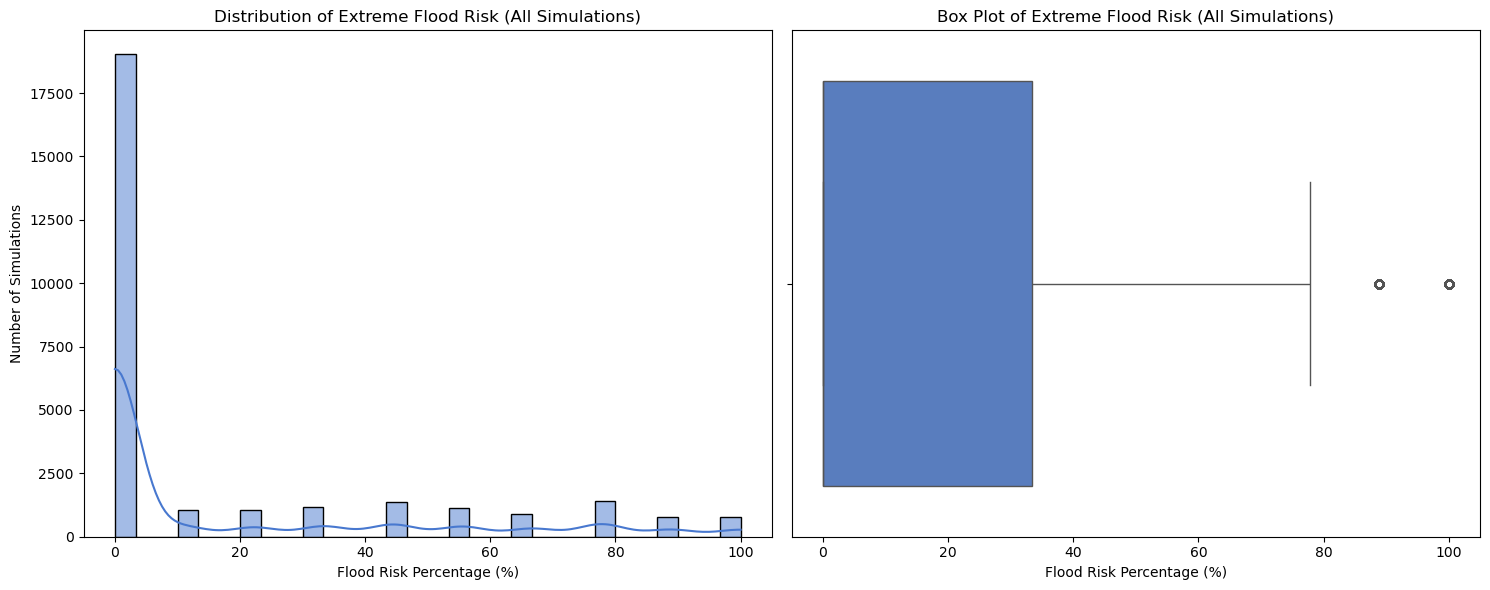


✅ All results saved to:
C:\Users\sl177\OneDrive - University of Illinois - Urbana\02_Paper Work\01_Paper(CANOPY)\01_SWAT Uncertainty\02_Sobol\9_Gumbel risk analysis\UCL_flood_anlaysis\UCL_Flood_Risk_Report_All_Simulations.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------------------------------
#  저장 경로 설정
# -------------------------------------------------------
save_path = r"C:\Users\sl177\OneDrive - University of Illinois - Urbana\02_Paper Work\01_Paper(CANOPY)\01_SWAT Uncertainty\02_Sobol\9_Gumbel risk analysis\UCL_flood_anlaysis"
os.makedirs(save_path, exist_ok=True)

n_obs = len(obs_sorted)
all_sims = [col for col in sim_df.columns if col.startswith("sim")]
total_sims = len(all_sims)

# =======================================================
#  1️⃣ Gumbel Example Plot: 5개 그룹 × 5개 시뮬레이션
# =======================================================

n_groups = 5
group_size = 5

# 전체를 균등 분할하여 시작 인덱스 생성
indices = np.linspace(0, total_sims - group_size, n_groups, dtype=int)

for g, start_idx in enumerate(indices):
    
    example_sims = all_sims[start_idx:start_idx + group_size]
    plt.figure(figsize=(12, 8))
    
    for col in example_sims:
        
        data_sorted = np.sort(sim_df[col].dropna().values)
        n_s = len(data_sorted)
        
        i_s = np.arange(1, n_s + 1)
        fi_s = (i_s - 0.44) / (n_s + 1 - 0.88)
        yi_s = -np.log(-np.log(fi_s))
        
        var_x = (a_param**2 / n_obs) * (1.17 + 0.196 * yi_s + 1.099 * yi_s**2)
        std_err = np.sqrt(var_x)
        ucl_s = (c_param + a_param * yi_s) + t_val * std_err
        
        exceed_mask = (data_sorted > ucl_s)
        risk_percent = (np.sum(exceed_mask) / n_s) * 100
        
        plt.plot(yi_s, data_sorted, marker='o',
                 label=f'{col} ({risk_percent:.1f}%)')
        
        if np.sum(exceed_mask) > 0:
            plt.scatter(yi_s[exceed_mask],
                        data_sorted[exceed_mask],
                        color='red', zorder=5)
    
    # 관측 기준선
    yi_range = np.linspace(analysis_df['Variate_yi'].min(),
                           analysis_df['Variate_yi'].max(), 100)

    var_range = (a_param**2 / n_obs) * (1.17 + 0.196 * yi_range + 1.099 * yi_range**2)

    ucl_range = (c_param + a_param * yi_range) + t_val * np.sqrt(var_range)
    lcl_range = (c_param + a_param * yi_range) - t_val * np.sqrt(var_range)
    x_est_range = c_param + a_param * yi_range

    plt.plot(yi_range, x_est_range, 'b-', linewidth=2, label='Obs Gumbel Fit')
    plt.plot(yi_range, ucl_range, 'r--', label='Obs 95% UCL')
    plt.plot(yi_range, lcl_range, 'r--', label='Obs 95% LCL')

    plt.scatter(analysis_df['Variate_yi'],
                analysis_df['Observed_X'],
                color='black', alpha=0.5,
                label='Observed Data')

    plt.title(f'Example Simulation Group {g+1} (5 cases)')
    plt.xlabel('Standardized Variate (yi)')
    plt.ylabel('Streamflow (cms)')
    plt.legend(fontsize=8)
    plt.grid(True, linestyle=':', alpha=0.6)

    file_name = f"Gumbel_Example_Group_{g+1}.png"
    plt.savefig(os.path.join(save_path, file_name),
                dpi=300, bbox_inches='tight')
    plt.show()

print("✅ Example groups saved.")


# =======================================================
#  2️⃣ 전체 시뮬레이션 Flood Risk 계산
# =======================================================

risk_results = []

for col in all_sims:
    
    data_sorted = np.sort(sim_df[col].dropna().values)
    n_s = len(data_sorted)
    
    i_s = np.arange(1, n_s + 1)
    fi_s = (i_s - 0.44) / (n_s + 1 - 0.88)
    yi_s = -np.log(-np.log(fi_s))
    
    var_x = (a_param**2 / n_obs) * (1.17 + 0.196 * yi_s + 1.099 * yi_s**2)
    std_err = np.sqrt(var_x)
    ucl_s = (c_param + a_param * yi_s) + t_val * std_err
    
    exceed_mask = (data_sorted > ucl_s)
    risk_percent = (np.sum(exceed_mask) / n_s) * 100
    
    risk_results.append({
        "Simulation": col,
        "Risk_Percentage": risk_percent
    })

risk_report_df = pd.DataFrame(risk_results)

print(f"\nTotal simulations analyzed: {len(risk_report_df)}")
print(f"Mean Flood Risk: {risk_report_df['Risk_Percentage'].mean():.2f}%")


# =======================================================
#  3️⃣ Flood Risk 분포 그래프 (전체)
# =======================================================

plt.style.use('seaborn-v0_8-muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(risk_report_df['Risk_Percentage'],
             bins=30, kde=True, ax=ax1)

ax1.set_title('Distribution of Extreme Flood Risk (All Simulations)')
ax1.set_xlabel('Flood Risk Percentage (%)')
ax1.set_ylabel('Number of Simulations')

sns.boxplot(x=risk_report_df['Risk_Percentage'], ax=ax2)

ax2.set_title('Box Plot of Extreme Flood Risk (All Simulations)')
ax2.set_xlabel('Flood Risk Percentage (%)')

plt.tight_layout()

plt.savefig(os.path.join(save_path,
                         "Flood_Risk_Distribution_All_Sims.png"),
            dpi=300, bbox_inches='tight')

plt.show()


# =======================================================
#  4️⃣ CSV 저장
# =======================================================

csv_path = os.path.join(save_path,
                        "UCL_Flood_Risk_Report_All_Simulations.csv")

risk_report_df.to_csv(csv_path, index=False)

print("\n✅ All results saved to:")
print(csv_path)